### Smartphone Battery Life Prediction using Linear Regression

#### In this notebook, we'll build a linear regression model to predict smartphone battery life
#### based on various specifications like screen size, battery capacity, processor speed, etc.

In [1]:
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Set random seed for reproducibility
np.random.seed(42)
# Generate 100 smartphone samples
n_samples = 100

In [4]:
# Generate features
screen_size = np.random.choice(np.arange(4, 8.1, 0.2), size=n_samples)  # Screen size in inches


In [5]:
# Generate target variable (battery life) with some noise
# We'll assume battery life is positively correlated with battery capacity
# and negatively correlated with screen size and processor speed
battery_life = (
    16  # Base battery life
    - (screen_size - 6.0) * 2  # Each inch difference from 6.0 adds/removes 2 hours
    + np.random.normal(0, 0.5, n_samples)  # Add small random variations
)
#battery_life is y(x,w)

In [6]:
# Create a DataFrame
data = pd.DataFrame({
    'screen_size': screen_size,
    'battery_life': battery_life
})

In [7]:
# Display first few rows of our dataset
print("First few rows of our dataset:")
print(data.head())

First few rows of our dataset:
   screen_size  battery_life
0          5.2     17.151832
1          7.8     12.344006
2          6.8     15.134471
3          6.0     15.438051
4          5.4     17.675003


Text(0.5, 1.0, 'Screen Size vs Battery Life')

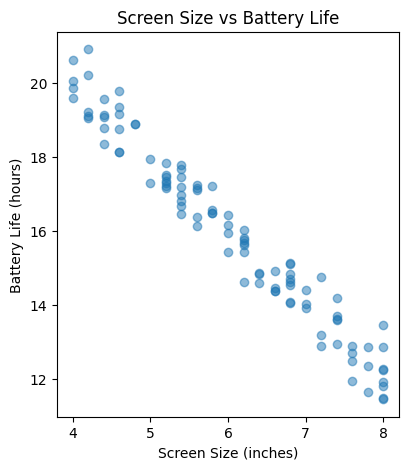

In [8]:
# Visualize relationships between features and target
plt.figure(figsize=(15, 5))
# Plot 1: Screen Size vs Battery Life
plt.subplot(131)
plt.scatter(data['screen_size'], data['battery_life'], alpha=0.5)
plt.xlabel('Screen Size (inches)')
plt.ylabel('Battery Life (hours)')
plt.title('Screen Size vs Battery Life')


Provare a risolvere questo dataset con la discesa del gradiente manuale

In [23]:
def compute_gradient(x, y, w1, w0): 
   """
   Calcola il gradiente per la regressione lineare 
   Args:
     x (ndarray (m,)): Dati, m esempi 
     y (ndarray (m,)): Valori target
     w1 (scalar)     : Parametro del modello per il coefficiente della variabile
     w0 (scalar)     : Parametro del modello per l'intercetta  
   Returns
     dj_dw1 (scalar): Il gradiente del costo rispetto al parametro w1
     dj_dw0 (scalar): Il gradiente del costo rispetto al parametro w0     
   """
   
   # Numero di esempi di training
   m = x.shape[0]    
   dj_dw1 = 0
   dj_dw0 = 0
   
   for n in range(m):  
       # Calcolo dell'output del modello per l'esempio n-esimo
       y_pred = w1 * x[n] + w0 
       
       # Calcolo del contributo dell'esempio n-esimo al gradiente rispetto a w1
       dj_dw1_i = (y_pred - y[n]) * x[n] 
       
       # Calcolo del contributo dell'esempio n-esimo al gradiente rispetto a w0
       dj_dw0_i = y_pred - y[n] 
       
       # Accumulo dei contributi
       dj_dw0 += dj_dw0_i
       dj_dw1 += dj_dw1_i 
   
   # Calcolo della media dei gradienti su tutti gli esempi
   dj_dw1 = dj_dw1 / m 
   dj_dw0 = dj_dw0 / m 
       
   return dj_dw1, dj_dw0

In [24]:
def compute_cost(x, y, w1, w0): 
   """
   Calcola la funzione di costo per la regressione lineare.
   
   Argomenti:
     x (ndarray (m,)): Dati di input, m esempi 
     y (ndarray (m,)): Valori target (output desiderato)
     w1, w0 (scalari)   : Parametri del modello  
   Restituisce:
       total_cost (float): Il costo dell'uso di w come parametri della regressione lineare
                          per adattare i punti dati in x e y.
   """
   # Numero di esempi di addestramento
   m = x.shape[0] 
   
   cost_sum = 0  # Inizializzazione della somma dei costi
   for n in range(m): 
       y_pred = w1 * x[n] + w0  # Calcola il valore predetto dal modello per l'n-esimo esempio
       cost = (y_pred - y[n]) ** 2  # Calcola l'errore quadratico
       cost_sum = cost_sum + cost  # Somma l'errore quadratico totale

   # Calcolo finale del costo medio normalizzato
   total_cost = (1 / (2)) * cost_sum  
   
   
   return total_cost

In [25]:
import math

def gradient_descent(x, y, w1_in, w0_in, alpha, num_iters, cost_function, gradient_function): 
   """
   Esegue la discesa del gradiente per trovare i valori ottimali di w1,w0. Aggiorna w1,w0 
   facendo num_iters passi di gradiente con tasso di apprendimento alpha
   
   Args:
     x (ndarray (m,))  : Dati, m esempi 
     y (ndarray (m,))  : Valori target
     w1_in,w0_in (scalar): Valori iniziali dei parametri del modello  
     alpha (float):     Tasso di apprendimento
     num_iters (int):   Numero di iterazioni per eseguire la discesa del gradiente
     cost_function:     Funzione da chiamare per calcolare il costo
     gradient_function: Funzione da chiamare per calcolare il gradiente
     
   Returns:
     w1 (scalar): Valore aggiornato del parametro dopo aver eseguito la discesa del gradiente
     w0 (scalar): Valore aggiornato del parametro dopo aver eseguito la discesa del gradiente
     J_history (List): Storico dei valori di costo
     p_history (list): Storico dei parametri [w1,w0] 
   """
   
   # Un array per memorizzare il costo J e i valori di w ad ogni iterazione, principalmente per la visualizzazione grafica successiva
   J_history = []
   p_history = []
   w0 = w0_in
   w1 = w1_in
   
   for i in range(num_iters):
       # Calcola il gradiente e aggiorna i parametri usando gradient_function
       dj_dw1, dj_dw0 = gradient_function(x, y, w1, w0)     
       # Aggiorna i parametri usando l'equazione (3) sopra
       w0 = w0 - alpha * dj_dw0                            
       w1 = w1 - alpha * dj_dw1                            
       # Salva il costo J ad ogni iterazione
       if i<100000:      # previene l'esaurimento delle risorse 
           J_history.append(cost_function(x, y, w1, w0))
           p_history.append([w1,w0])
       # Stampa il costo a intervalli 10 volte o tante iterazioni se < 10
       if i% math.ceil(num_iters/10) == 0:
           print(f"Iterazione {i:4}: Costo {J_history[-1]:0.2e} ",
                 f"dj_dw1: {dj_dw1: 0.3e}, dj_dw0: {dj_dw0: 0.3e}  ",
                 f"w1: {w1: 0.3e}, w0:{w0: 0.5e}")

   return w1, w0, J_history, p_history # restituisce w e lo storico di J,w per la visualizzazione grafica

In [26]:
w1_init = -2
w0_init = 22
#Settings della discesa
iterations = 10000
tmp_alpha = 1.0e-2

w_final, b_final, E_hist, p_hist = gradient_descent(screen_size ,battery_life, w1_init, w0_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w1,w0) minimo: ({w_final:8.4f},{b_final:8.4f})")

Iterazione    0: Costo 9.60e+02  dj_dw1: -3.603e+01, dj_dw0: -6.000e+00   w1: -1.640e+00, w0: 2.20600e+01
Iterazione 1000: Costo 2.71e+02  dj_dw1:  2.566e-02, dj_dw0: -1.605e-01   w1: -1.379e+00, w0: 2.41024e+01
Iterazione 2000: Costo 2.53e+02  dj_dw1:  1.757e-02, dj_dw0: -1.099e-01   w1: -1.593e+00, w0: 2.54382e+01
Iterazione 3000: Costo 2.44e+02  dj_dw1:  1.203e-02, dj_dw0: -7.525e-02   w1: -1.739e+00, w0: 2.63528e+01
Iterazione 4000: Costo 2.40e+02  dj_dw1:  8.237e-03, dj_dw0: -5.152e-02   w1: -1.839e+00, w0: 2.69791e+01
Iterazione 5000: Costo 2.38e+02  dj_dw1:  5.640e-03, dj_dw0: -3.528e-02   w1: -1.907e+00, w0: 2.74079e+01
Iterazione 6000: Costo 2.37e+02  dj_dw1:  3.862e-03, dj_dw0: -2.416e-02   w1: -1.954e+00, w0: 2.77015e+01
Iterazione 7000: Costo 2.37e+02  dj_dw1:  2.644e-03, dj_dw0: -1.654e-02   w1: -1.987e+00, w0: 2.79026e+01
Iterazione 8000: Costo 2.36e+02  dj_dw1:  1.811e-03, dj_dw0: -1.133e-02   w1: -2.009e+00, w0: 2.80403e+01
Iterazione 9000: Costo 2.36e+02  dj_dw1:  1.24

# Modelli con Caratteristiche Multiple

Sebbene l'esempio nella sezione precedente utilizzi una sola caratteristica, un modello più sofisticato potrebbe basarsi su più caratteristiche, ciascuna con un peso diverso ($w_1$, $w_2$) e così via.

Per esempio, un modello basato su caratteristiche multiple potrebbe essere scritto come:

$$y(x,w) = w_0 + w_1x_1 + w_2x_2 + w_3x_3$$

Ad esempio, un modello che prevede la durata della batteria di uno smartphone potrebbe utilizzare queste caratteristiche:
* Dimensione dello schermo → $x_1$
* Capacità della batteria → $x_2$
* Velocità del processore → $x_3$

Questo modello sarebbe scritto come:

$\hat{y} = w_0 + w_1 \cdot \text{dimensione\_schermo} + w_2 \cdot \text{capacità\_batteria} + w_3 \cdot \text{velocità\_processore}$

dove:
* $\hat{y}$ è la durata della batteria prevista
* $w_0$ è il bias del modello
* $w_1, w_2, w_3$ sono i pesi associati a ciascuna caratteristica
* $\text{dimensione\_schermo}, \text{capacità\_batteria}, \text{velocità\_processore}$ sono le caratteristiche di input

Questi pesi vengono appresi durante l'addestramento per minimizzare l'errore nella previsione della durata della batteria.

In [9]:
battery_capacity = np.random.uniform(3000, 5000, n_samples)  # Battery capacity in mAh
processor_speed = np.random.uniform(1.8, 3.2, n_samples)  # Processor speed in GHz

In [10]:
# Generate target variable (battery life) with some noise
# We'll assume battery life is positively correlated with battery capacity
# and negatively correlated with screen size and processor speed
battery_life = (
    16  # Base battery life
    + (battery_capacity - 4000) * 0.003  # Each 1000mAh adds/removes ~3 hours
    - (screen_size - 6.0) * 2  # Each inch difference from 6.0 adds/removes 2 hours
    - (processor_speed - 2.5) * 3  # Each GHz difference from 2.5 adds/removes 3 hours
    + np.random.normal(0, 0.5, n_samples)  # Add small random variations
)

In [11]:
# Create a DataFrame
data = pd.DataFrame({
    'screen_size': screen_size,
    'battery_capacity': battery_capacity,
    'processor_speed': processor_speed,
    'battery_life': battery_life
})

In [12]:
# Display first few rows of our dataset
print("First few rows of our dataset:")
print(data.head())

First few rows of our dataset:
   screen_size  battery_capacity  processor_speed  battery_life
0          5.2       4400.715660         2.959017     16.658065
1          7.8       4693.322284         2.180160     15.621021
2          6.8       4712.648584         3.151353     15.156074
3          6.0       3809.016254         2.440171     16.035467
4          5.4       4775.540198         2.978832     17.776695


Text(0.5, 1.0, 'Screen Size vs Battery Life')

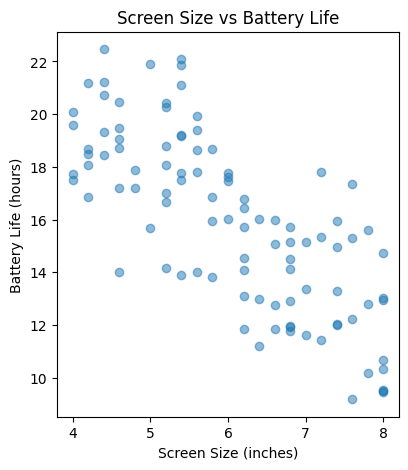

In [13]:
# Visualize relationships between features and target
plt.figure(figsize=(15, 5))
# Plot 1: Screen Size vs Battery Life
plt.subplot(131)
plt.scatter(data['screen_size'], data['battery_life'], alpha=0.5)
plt.xlabel('Screen Size (inches)')
plt.ylabel('Battery Life (hours)')
plt.title('Screen Size vs Battery Life')

Text(0.5, 1.0, 'Battery Capacity vs Battery Life')

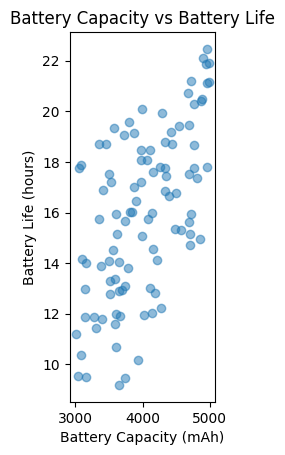

In [14]:
# Plot 2: Battery Capacity vs Battery Life
plt.subplot(132)
plt.scatter(data['battery_capacity'], data['battery_life'], alpha=0.5)
plt.xlabel('Battery Capacity (mAh)')
plt.ylabel('Battery Life (hours)')
plt.title('Battery Capacity vs Battery Life')

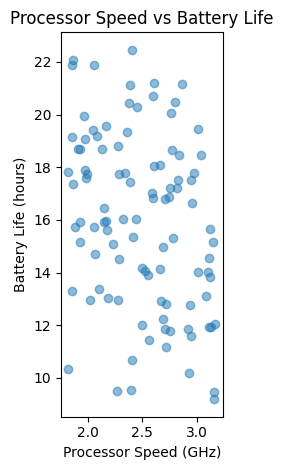

In [15]:
# Plot 3: Processor Speed vs Battery Life
plt.subplot(133)
plt.scatter(data['processor_speed'], data['battery_life'], alpha=0.5)
plt.xlabel('Processor Speed (GHz)')
plt.ylabel('Battery Life (hours)')
plt.title('Processor Speed vs Battery Life')

plt.tight_layout()
plt.show()


In [16]:
# Prepare features (X) and target (y)
X = data[['screen_size', 'battery_capacity', 'processor_speed']]
y = data['battery_life']

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Print model performance metrics
print("\nModel Performance Metrics:")
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))


Model Performance Metrics:
Root Mean Squared Error: 0.4949118453337992


In [18]:
# Print model coefficients
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


Model Coefficients:
screen_size: -2.0225
battery_capacity: 0.0031
processor_speed: -2.7179
Intercept: 22.6554


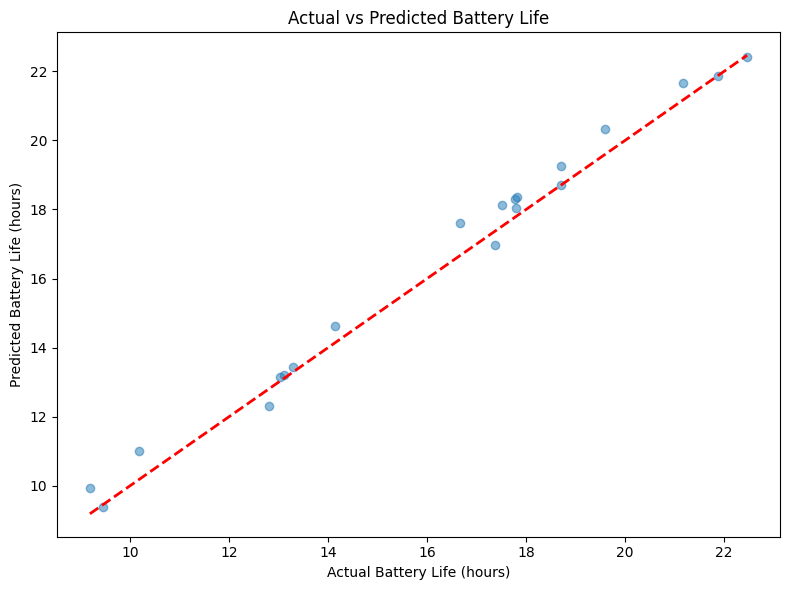

In [19]:
# Visualize actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Battery Life (hours)')
plt.ylabel('Predicted Battery Life (hours)')
plt.title('Actual vs Predicted Battery Life')
plt.tight_layout()
plt.show()

In [20]:
# Pesi reali utilizzati per generare i dati
real_weights = {
    'screen_size': -2.0,  # Ogni pollice di differenza da 6.0 aggiunge/rimuove 2 ore
    'battery_capacity': 0.003,  # Ogni 1000mAh aggiunge/rimuove ~3 ore
    'processor_speed': -3.0  # Ogni GHz di differenza da 2.5 aggiunge/rimuove 3 ore
}

# Pesi trovati dal modello
model_weights = dict(zip(X.columns, model.coef_))

# Confronto fra pesi reali e pesi trovati
print("Confronto fra pesi reali e pesi trovati:")
for feature in real_weights:
    print(f"{feature}:")
    print(f"  Peso reale: {real_weights[feature]:.4f}")
    print(f"  Peso trovato: {model_weights[feature]:.4f}")

Confronto fra pesi reali e pesi trovati:
screen_size:
  Peso reale: -2.0000
  Peso trovato: -2.0225
battery_capacity:
  Peso reale: 0.0030
  Peso trovato: 0.0031
processor_speed:
  Peso reale: -3.0000
  Peso trovato: -2.7179
